# Import needed modules

In [1]:
# import system libs
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')


modules loaded


# Create needed functions

## Functions to Create Data Frame from Dataset

#### **Function to create data frame**

In [2]:
# Generate data paths with labels
def define_paths(data_dir):
    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    return filepaths, labels


# Concatenate data paths with labels into one dataframe ( to later be fitted into the model )
def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    return pd.concat([Fseries, Lseries], axis= 1)

# Split dataframe to train, valid, and test
def split_data(data_dir):
    # train dataframe
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df['labels']
    train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

    # valid and test dataframe
    strat = dummy_df['labels']
    valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

    return train_df, valid_df, test_df

#### Function to generate images from dataframe

In [3]:
def create_gens (train_df, valid_df, test_df, batch_size):
    '''
    This function takes train, validation, and test dataframe and fit them into image data generator, because model takes data from image data generator.
    Image data generator converts images into tensors. '''


    # define model parameters
    img_size = (224, 224)
    channels = 3 # either BGR or Grayscale
    color = 'rgb'
    img_shape = (img_size[0], img_size[1], channels)

    # Recommended : use custom function for test data batch size, else we can use normal batch size.
    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
    test_steps = ts_length // test_batch_size

    # This function which will be used in image data generator for data augmentation, it just take the image and return it again.
    def scalar(img):
        return img

    # ✅ IMPROVED: Stronger augmentation to reduce overfitting
    tr_gen = ImageDataGenerator(
        preprocessing_function=scalar,
        horizontal_flip=True,
        vertical_flip=False,          # عيون لا تحتاج vertical flip
        rotation_range=15,            # تدوير خفيف
        zoom_range=0.1,               # تكبير/تصغير خفيف
        width_shift_range=0.1,        # إزاحة أفقية
        height_shift_range=0.1,       # إزاحة رأسية
        brightness_range=[0.85, 1.15] # تغيير الإضاءة
    )
    ts_gen = ImageDataGenerator(preprocessing_function= scalar)

    train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= True, batch_size= batch_size)

    # Note: we will use custom test_batch_size, and make shuffle= false
    test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= color, shuffle= False, batch_size= test_batch_size)

    return train_gen, valid_gen, test_gen


#### **Function to display data sample**

In [4]:
def show_images(gen):
    '''
    This function take the data generator and show sample of the images
    '''

    # return classes , images to be displayed
    g_dict = gen.class_indices        # defines dictionary {'class': index}
    classes = list(g_dict.keys())     # defines list of dictionary's kays (classes), classes names : string
    images, labels = next(gen)        # get a batch size samples from the generator

    # calculate number of displayed samples
    length = len(labels)        # length of batch size
    sample = min(length, 25)    # check if sample less than 25 images

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255       # scales data to range (0 - 255)
        plt.imshow(image)
        index = np.argmax(labels[i])  # get image index
        class_name = classes[index]   # get class of image
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

#### **Callbacks** 
<br> 
Callbacks : Helpful functions to help optimize model training  <br> 
Examples: stop model training after specfic time, stop training if no improve in accuracy and so on.

In [5]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.model = model
        self.patience = patience
        self.stop_patience = stop_patience
        self.threshold = threshold
        self.factor = factor
        self.batches = batches
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch
        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr))
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.best_weights = self.model.get_weights()
        self.initial_weights = self.model.get_weights()

    def on_train_begin(self, logs=None):
        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print(msg)

        self.model.set_weights(self.best_weights)

    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
        print(msg, '\r', end='')

    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        current_lr = lr
        acc = logs.get('accuracy')
        v_acc = logs.get('val_accuracy')
        loss = logs.get('loss')
        v_loss = logs.get('val_loss')

        if acc < self.threshold:
            monitor = 'accuracy'
            if epoch == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1

            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                    self.count = 0
                    self.stop_count = self.stop_count + 1
                    self.count = 0
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1

        else:
            monitor = 'val_loss'
            if epoch == 0:
                pimprov = 0.0

            else:
                pimprov = (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1

            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.stop_count = self.stop_count + 1
                    self.count = 0
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                else:
                    self.count = self.count + 1

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True


In [6]:
# class MyCallback(keras.callbacks.Callback):
#     def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
#         super(MyCallback, self).__init__()
#         self.model = model
#         self.patience = patience # specifies how many epochs without improvement before learning rate is adjusted
#         self.stop_patience = stop_patience # specifies how many times to adjust lr without improvement to stop training
#         self.threshold = threshold # specifies training accuracy threshold when lr will be adjusted based on validation loss
#         self.factor = factor # factor by which to reduce the learning rate
#         self.batches = batches # number of training batch to run per epoch
#         self.epochs = epochs
#         self.ask_epoch = ask_epoch
#         self.ask_epoch_initial = ask_epoch # save this value to restore if restarting training

#         # callback variables
#         self.count = 0 # how many times lr has been reduced without improvement
#         self.stop_count = 0
#         self.best_epoch = 1   # epoch with the lowest loss
#         self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr)) # get the initial learning rate and save it
#         self.highest_tracc = 0.0 # set highest training accuracy to 0 initially
#         self.lowest_vloss = np.inf # set lowest validation loss to infinity initially
#         self.best_weights = self.model.get_weights() # set best weights to model's initial weights
#         self.initial_weights = self.model.get_weights()   # save initial weights if they have to get restored

#     # Define a function that will run when train begins
#     def on_train_begin(self, logs= None):
#         msg = 'Do you want model asks you to halt the training [y/n] ?'
#         print(msg)
#         ans = input('')
#         if ans in ['Y', 'y']:
#             self.ask_permission = 1
#         elif ans in ['N', 'n']:
#             self.ask_permission = 0

#         msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
#         print(msg)
#         self.start_time = time.time()


#     def on_train_end(self, logs= None):
#         stop_time = time.time()
#         tr_duration = stop_time - self.start_time
#         hours = tr_duration // 3600
#         minutes = (tr_duration - (hours * 3600)) // 60
#         seconds = tr_duration - ((hours * 3600) + (minutes * 60))

#         msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
#         print(msg)

#         # set the weights of the model to the best weights
#         self.model.set_weights(self.best_weights)


#     def on_train_batch_end(self, batch, logs= None):
#         # get batch accuracy and loss
#         acc = logs.get('accuracy') * 100
#         loss = logs.get('loss')

#         # prints over on the same line to show running batch count
#         msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(' ', str(batch), str(self.batches), acc, loss)
#         print(msg, '\r', end= '')


#     def on_epoch_begin(self, epoch, logs= None):
#         self.ep_start = time.time()


#     # Define method runs on the end of each epoch
#     def on_epoch_end(self, epoch, logs= None):
#         ep_end = time.time()
#         duration = ep_end - self.ep_start

#         lr = float(tf.keras.backend.get_value(self.model.optimizer.lr)) # get the current learning rate
#         current_lr = lr
#         acc = logs.get('accuracy')  # get training accuracy
#         v_acc = logs.get('val_accuracy')  # get validation accuracy
#         loss = logs.get('loss')  # get training loss for this epoch
#         v_loss = logs.get('val_loss')  # get the validation loss for this epoch

#         if acc < self.threshold: # if training accuracy is below threshold adjust lr based on training accuracy
#             monitor = 'accuracy'
#             if epoch == 0:
#                 pimprov = 0.0
#             else:
#                 pimprov = (acc - self.highest_tracc ) * 100 / self.highest_tracc # define improvement of model progres

#             if acc > self.highest_tracc: # training accuracy improved in the epoch
#                 self.highest_tracc = acc # set new highest training accuracy
#                 self.best_weights = self.model.get_weights() # training accuracy improved so save the weights
#                 self.count = 0 # set count to 0 since training accuracy improved
#                 self.stop_count = 0 # set stop counter to 0
#                 if v_loss < self.lowest_vloss:
#                     self.lowest_vloss = v_loss
#                 self.best_epoch = epoch + 1  # set the value of best epoch for this epoch

#             else:
#                 # training accuracy did not improve check if this has happened for patience number of epochs
#                 # if so adjust learning rate
#                 if self.count >= self.patience - 1: # lr should be adjusted
#                     lr = lr * self.factor # adjust the learning by factor
#                     tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer
#                     self.count = 0 # reset the count to 0
#                     self.stop_count = self.stop_count + 1 # count the number of consecutive lr adjustments
#                     self.count = 0 # reset counter
#                     if v_loss < self.lowest_vloss:
#                         self.lowest_vloss = v_loss
#                 else:
#                     self.count = self.count + 1 # increment patience counter

#         else: # training accuracy is above threshold so adjust learning rate based on validation loss
#             monitor = 'val_loss'
#             if epoch == 0:
#                 pimprov = 0.0

#             else:
#                 pimprov = (self.lowest_vloss - v_loss ) * 100 / self.lowest_vloss

#             if v_loss < self.lowest_vloss: # check if the validation loss improved
#                 self.lowest_vloss = v_loss # replace lowest validation loss with new validation loss
#                 self.best_weights = self.model.get_weights() # validation loss improved so save the weights
#                 self.count = 0 # reset count since validation loss improved
#                 self.stop_count = 0
#                 self.best_epoch = epoch + 1 # set the value of the best epoch to this epoch

#             else: # validation loss did not improve
#                 if self.count >= self.patience - 1: # need to adjust lr
#                     lr = lr * self.factor # adjust the learning rate
#                     self.stop_count = self.stop_count + 1 # increment stop counter because lr was adjusted
#                     self.count = 0 # reset counter
#                     tf.keras.backend.set_value(self.model.optimizer.lr, lr) # set the learning rate in the optimizer

#                 else:
#                     self.count = self.count + 1 # increment the patience counter

#                 if acc > self.highest_tracc:
#                     self.highest_tracc = acc

#         msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
#         print(msg)

#         if self.stop_count > self.stop_patience - 1: # check if learning rate has been adjusted stop_count times with no improvement
#             msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
#             print(msg)
#             self.model.stop_training = True # stop training

#         else:
#             if self.ask_epoch != None and self.ask_permission != 0:
#                 if epoch + 1 >= self.ask_epoch:
#                     msg = 'enter H to halt training or an integer for number of epochs to run then ask again'
#                     print(msg)

#                     ans = input('')
#                     if ans == 'H' or ans == 'h':
#                         msg = f'training has been halted at epoch {epoch + 1} due to user input'
#                         print(msg)
#                         self.model.stop_training = True # stop training

#                     else:
#                         try:
#                             ans = int(ans)
#                             self.ask_epoch += ans
#                             msg = f' training will continue until epoch {str(self.ask_epoch)}'
#                             print(msg)
#                             msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration')
#                             print(msg)

#                         except Exception:
#                             print('Invalid')

#### **Function to plot history of training**

In [7]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # ✅ IMPROVED: Cleaner, more professional plot style
    plt.style.use('default')
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor('#F8F9FB')

    TRAIN_COLOR = '#E84545'
    VAL_COLOR   = '#2ECC71'
    BEST_COLOR  = '#3B82F6'
    GRID_COLOR  = '#E2E8EF'

    for ax in axes:
        ax.set_facecolor('#FFFFFF')
        ax.grid(True, color=GRID_COLOR, linewidth=0.8, linestyle='-')
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_edgecolor('#D1D5DB')
            spine.set_linewidth(0.8)

    # Loss subplot
    axes[0].fill_between(Epochs, tr_loss, alpha=0.10, color=TRAIN_COLOR)
    axes[0].fill_between(Epochs, val_loss, alpha=0.10, color=VAL_COLOR)
    axes[0].plot(Epochs, tr_loss, color=TRAIN_COLOR, linewidth=2.2, label='Training loss')
    axes[0].plot(Epochs, val_loss, color=VAL_COLOR, linewidth=2.2, label='Validation loss')
    axes[0].scatter(index_loss + 1, val_lowest, s=150, color=BEST_COLOR, zorder=5, label=loss_label)
    axes[0].set_title('Training and Validation Loss', fontsize=13, fontweight='bold', color='#111827', pad=10)
    axes[0].set_xlabel('Epochs', fontsize=11, color='#374151')
    axes[0].set_ylabel('Loss', fontsize=11, color='#374151')
    axes[0].legend(fontsize=10, framealpha=0.95, edgecolor='#D1D5DB')

    # Accuracy subplot
    axes[1].fill_between(Epochs, tr_acc, alpha=0.10, color=TRAIN_COLOR)
    axes[1].fill_between(Epochs, val_acc, alpha=0.10, color=VAL_COLOR)
    axes[1].plot(Epochs, tr_acc, color=TRAIN_COLOR, linewidth=2.2, label='Training Accuracy')
    axes[1].plot(Epochs, val_acc, color=VAL_COLOR, linewidth=2.2, label='Validation Accuracy')
    axes[1].scatter(index_acc + 1, acc_highest, s=150, color=BEST_COLOR, zorder=5, label=acc_label)
    axes[1].set_title('Training and Validation Accuracy', fontsize=13, fontweight='bold', color='#111827', pad=10)
    axes[1].set_xlabel('Epochs', fontsize=11, color='#374151')
    axes[1].set_ylabel('Accuracy', fontsize=11, color='#374151')
    axes[1].legend(fontsize=10, framealpha=0.95, edgecolor='#D1D5DB', loc='lower right')

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


#### **Function to create Confusion Matrix**

In [8]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):
	'''
	This function plot confusion matrix method from sklearn package.
	'''

	plt.figure(figsize= (10, 10))
	plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
	plt.title(title)
	plt.colorbar()

	tick_marks = np.arange(len(classes))
	plt.xticks(tick_marks, classes, rotation= 45)
	plt.yticks(tick_marks, classes)

	if normalize:
		cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
		print('Normalized Confusion Matrix')

	else:
		print('Confusion Matrix, Without Normalization')

	print(cm)

	thresh = cm.max() / 2.
	for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
		plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

	plt.tight_layout()
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')

# **Model Structure**

#### **Start Reading Dataset**

In [11]:
data_dir = 'E:\Graduation Project\AI Models\Eye Model\dataset'


try:
    # Get splitted data
    train_df, valid_df, test_df = split_data(data_dir)

    # Get Generators
    batch_size = 40
    train_gen, valid_gen, test_gen = create_gens(train_df, valid_df, test_df, batch_size)

except:
    print('Invalid Input')

Found 3373 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.


In [12]:
print(os.listdir(data_dir))

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


#### **Display Image Sample**

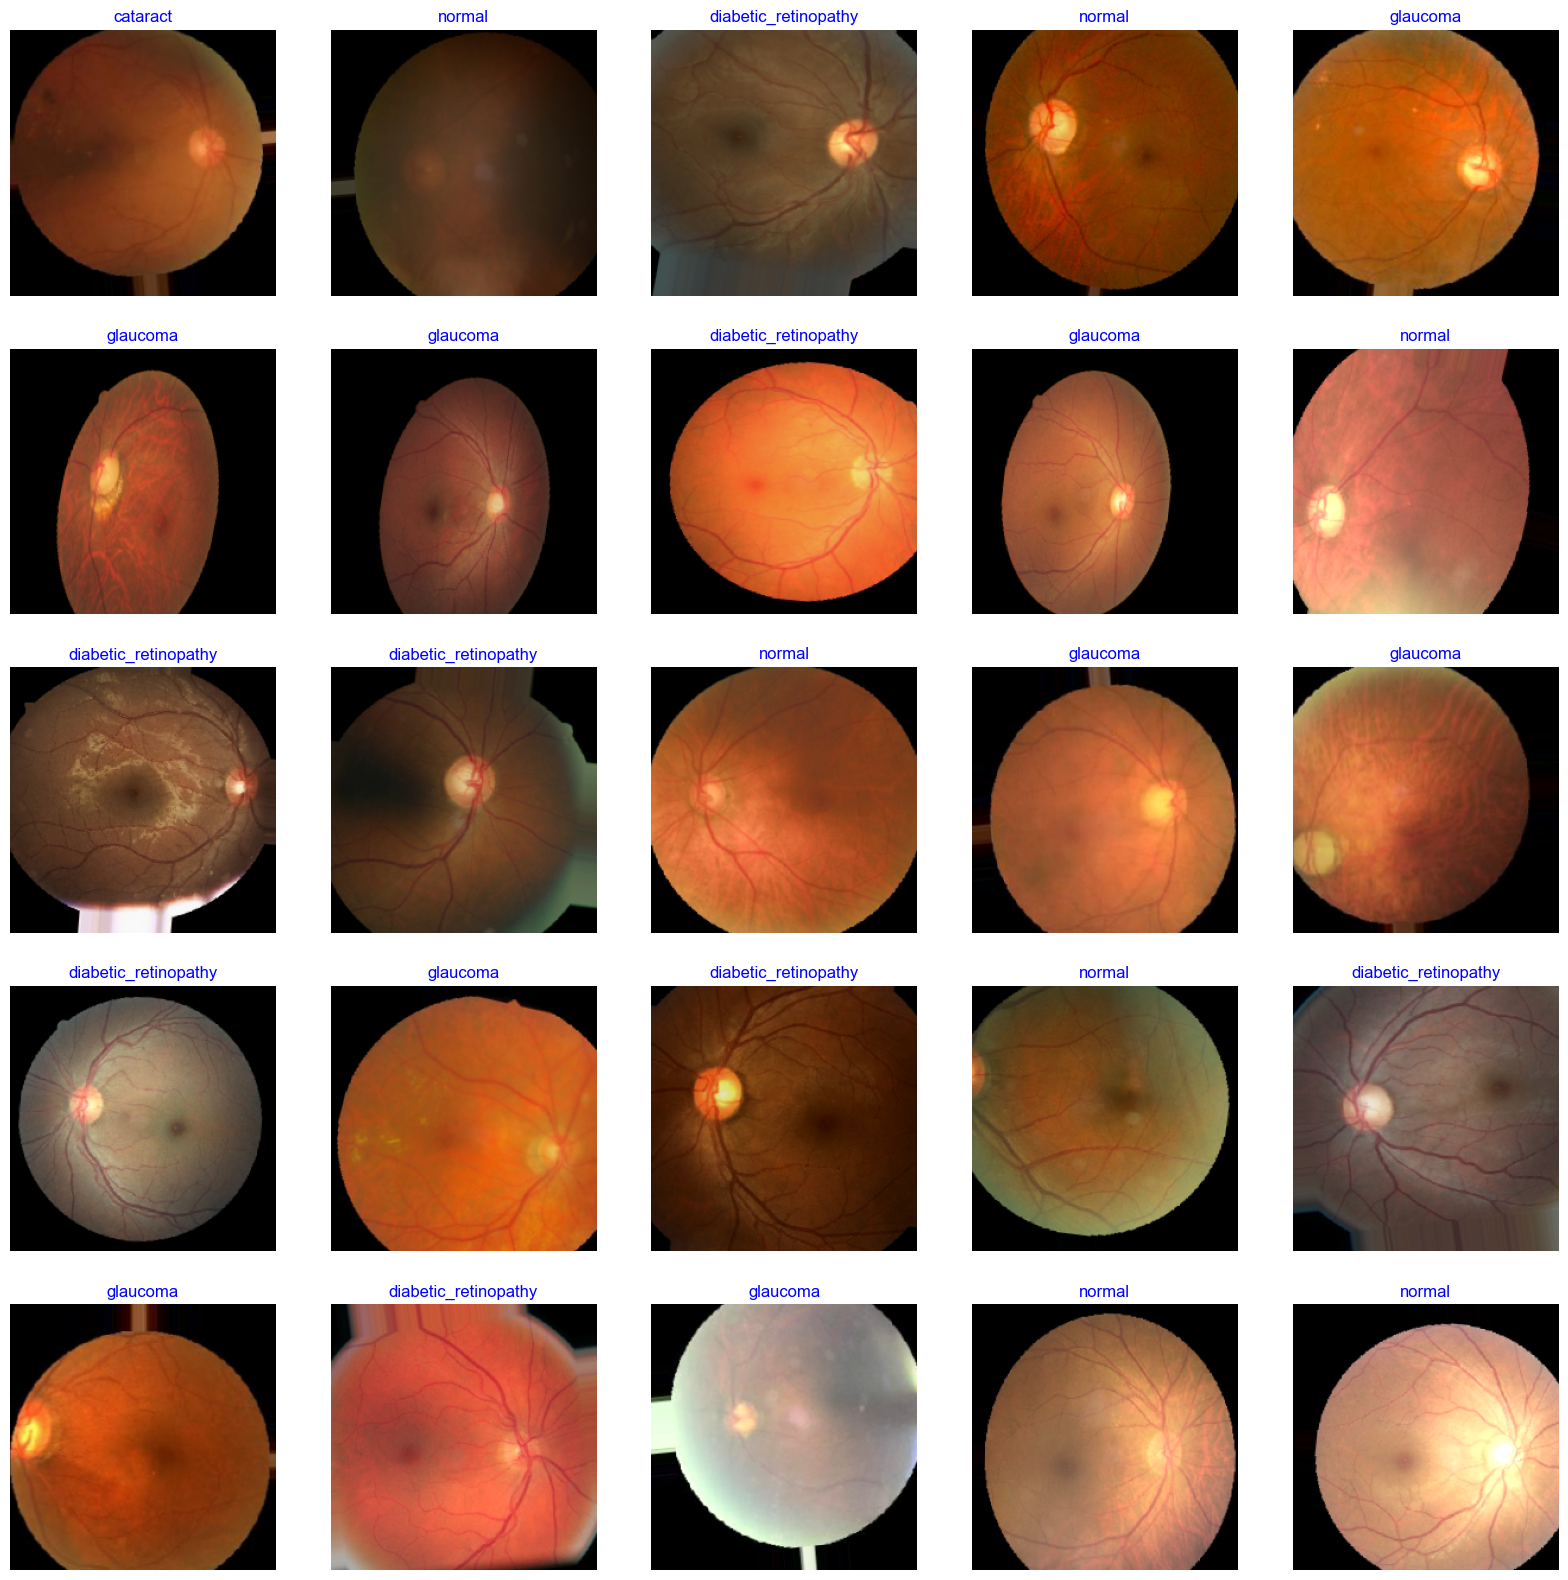

In [13]:
show_images(train_gen)

#### **Generic Model Creation**

In [14]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.efficientnet.EfficientNetB3(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')

#  IMPROVED: Unfreeze last 20 layers for fine-tuning (improves validation accuracy)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(l= 0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.50, seed= 123),  # ✅ IMPROVED: زيادة Dropout من 0.45 إلى 0.50 لتقليل overfitting
    Dense(class_count, activation= 'softmax')
])

# ✅ IMPROVED: تقليل learning rate قليلاً مع fine-tuning
model.compile(Adamax(learning_rate= 0.0005), loss= 'categorical_crossentropy', metrics= ['accuracy'])

model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional  (None, 1536)              10783535  
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 1536)              6144      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 11184179 (42.66 MB)
Trainable params: 3

#### **Set Callback Parameters**

In [15]:
batch_size = 40   # set batch size for training
epochs = 70   # ✅ IMPROVED: زيادة epochs مع Early Stopping (الـ callback هيوقف لوحده)
patience = 2   # ✅ IMPROVED: زيادة patience من 1 إلى 2 لتجنب التوقف المبكر جداً
stop_patience = 4   # ✅ IMPROVED: زيادة stop_patience من 3 إلى 4
threshold = 0.9   # if train accuracy is < threshold adjust monitor accuracy, else monitor validation loss
factor = 0.5   # factor to reduce lr by
ask_epoch = 5   # number of epochs to run before asking if you want to halt training
batches = int(np.ceil(len(train_gen.labels) / batch_size))    # number of training batch to run per epoch

callbacks = [MyCallback(model= model, patience= patience, stop_patience= stop_patience, threshold= threshold,
            factor= factor, batches= batches, epochs= epochs, ask_epoch= ask_epoch )]

# ✅ IMPROVED: Early Stopping على val_loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ✅ IMPROVED: ReduceLROnPlateau كـ backup للـ learning rate scheduler
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [MyCallback(model=model, patience=patience, stop_patience=stop_patience, threshold=threshold,
             factor=factor, batches=batches, epochs=epochs, ask_epoch=ask_epoch),
             early_stop, reduce_lr]


#### **Train model**

In [16]:
history = model.fit(x= train_gen, epochs= epochs, verbose= 0, callbacks= callbacks,
                    validation_data= valid_gen, validation_steps= None, shuffle= False)

 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration

 1 /70     8.253   66.202   7.53823  75.592   0.00050  0.00050  accuracy     0.00    222.89 
 2 /70     7.011   78.713   6.44961  84.360   0.00050  0.00050  accuracy    18.90    159.28 


KeyboardInterrupt: 

#### **Display model performance**

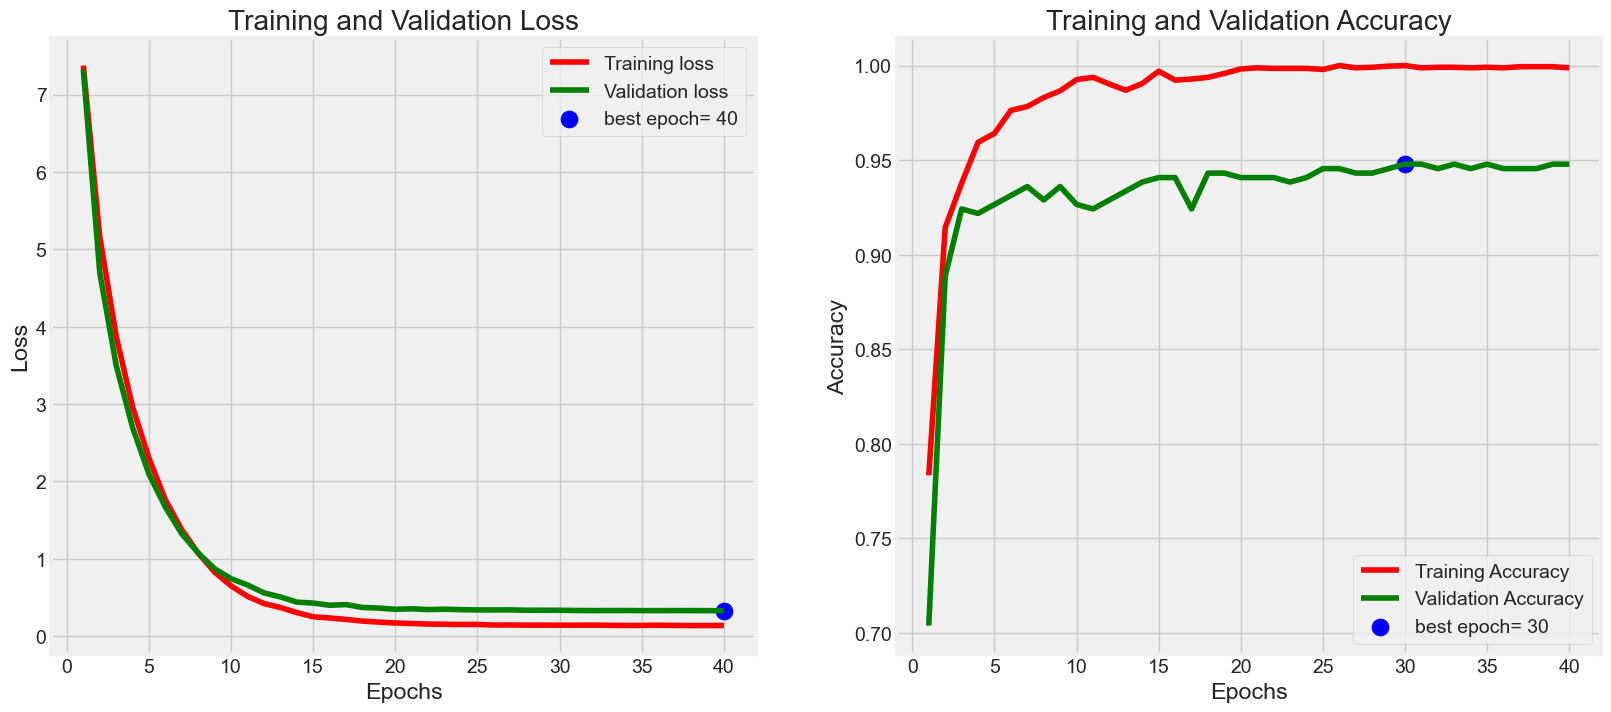

In [ ]:
plot_training(history)

# **Evaluate model**

In [ ]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

211/211 [==============================] - 39s 181ms/step - loss: 0.3219 - accuracy: 0.9526
Train Loss:  0.12035133689641953
Train Accuracy:  1.0
--------------------
Validation Loss:  0.3298960030078888
Validation Accuracy:  0.9478672742843628
--------------------
Test Loss:  0.3218573331832886
Test Accuracy:  0.9526066184043884


In [ ]:
loss, accuracy = model.evaluate(test_gen)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


211/211 [==============================] - 38s 179ms/step - loss: 0.3219 - accuracy: 0.9526
Test Accuracy: 95.26%


# **Get Predictions**

In [ ]:
preds = model.predict_generator(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred)

[1 2 2 3 3 1 3 3 0 2 1 3 2 1 3 3 0 2 3 1 3 0 2 1 0 0 2 3 1 2 1 3 3 1 2 2 1
 3 0 2 1 0 2 0 1 3 1 1 2 1 0 3 3 3 1 1 2 0 2 1 3 0 3 1 0 2 0 0 2 1 2 0 1 1
 1 2 2 0 1 1 2 2 0 0 3 3 2 2 2 0 2 2 0 1 2 2 2 1 3 3 3 3 0 2 0 3 0 0 1 2 3
 1 1 3 3 3 0 1 0 2 2 2 2 1 0 3 2 0 0 2 0 2 3 2 0 1 2 1 0 1 1 3 0 0 1 0 3 1
 2 3 1 0 3 3 2 2 2 0 2 1 2 3 3 3 0 0 0 2 0 0 0 3 2 2 2 0 0 2 1 0 1 0 3 2 0
 0 0 1 3 2 0 1 2 3 0 3 1 3 3 2 0 3 1 3 0 3 1 1 1 1 3 3 1 3 0 2 2 0 1 3 0 2
 0 1 0 3 0 2 3 3 3 0 2 2 1 2 2 0 3 0 1 0 1 0 3 1 3 3 2 1 0 3 1 2 2 3 2 0 1
 3 1 1 2 0 0 2 1 3 3 1 2 1 1 0 1 1 0 3 2 1 3 0 3 3 1 3 1 2 2 1 0 2 3 3 1 1
 3 1 3 2 2 2 3 1 2 1 2 1 2 0 0 0 3 3 3 1 2 1 3 3 1 0 3 1 3 0 0 3 0 3 1 0 1
 1 3 0 0 0 1 0 0 1 0 2 2 2 1 3 1 3 1 1 0 1 1 2 1 1 2 0 2 0 1 1 3 2 1 1 3 2
 3 0 3 2 1 3 0 3 3 3 2 1 2 1 1 3 2 1 1 2 1 3 0 2 2 0 0 2 0 3 2 3 0 0 2 1 2
 0 0 0 3 1 3 0 0 3 1 3 1 2 0 3]


In [ ]:
y_true = test_gen.classes

print("Predicted:", y_pred[:10])
print("Actual   :", y_true[:10])

Predicted: [1 2 2 3 3 1 3 3 0 2]
Actual   : [1, 2, 2, 3, 2, 1, 3, 3, 0, 2]


#### **Confusion Matrics and Classification Report**

Confusion Matrix, Without Normalization
[[101   0   2   1]
 [  0 110   0   0]
 [  1   0  93   7]
 [  2   0   7  98]]
                      precision    recall  f1-score   support

            cataract       0.97      0.97      0.97       104
diabetic_retinopathy       1.00      1.00      1.00       110
            glaucoma       0.91      0.92      0.92       101
              normal       0.92      0.92      0.92       107

            accuracy                           0.95       422
           macro avg       0.95      0.95      0.95       422
        weighted avg       0.95      0.95      0.95       422



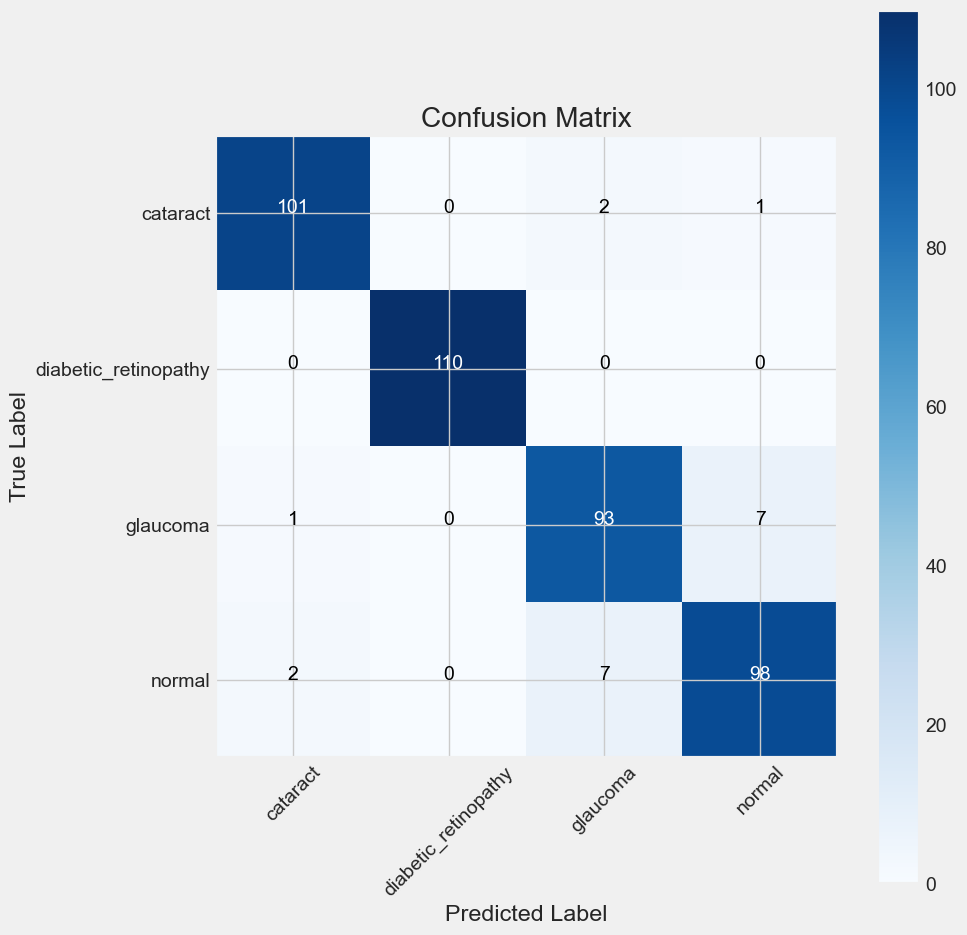

In [ ]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm= cm, classes= classes, title = 'Confusion Matrix')

# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

#### **Save model**

In [ ]:
model_name = model.input_names[0][:-6]
subject = 'Eye Disease'
acc = test_score[1] * 100
save_path = ''

# Save model
save_id = str(f'{model_name}-{subject}-{"%.2f" %round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model.save(model_save_loc)
print(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{model_name}-{subject}-weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')

model was saved as efficientnetb3-Eye Disease-95.26.h5
weights were saved as efficientnetb3-Eye Disease-weights.h5


In [ ]:
model_name = model.input_names[0][:-6]
subject = 'Eye Disease'
acc = test_score[1] * 100
save_path = ''  
# Save model as .keras
save_id_keras = f'{model_name}-{subject}-{acc:.2f}.keras'
model_save_loc_keras = os.path.join(save_path, save_id_keras)

model.save(model_save_loc_keras)
print(f'model was saved as {model_save_loc_keras}')


model was saved as efficientnetb3-Eye Disease-95.26.keras


#### **Generate CSV files containing classes indicies & image size**

In [ ]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')


class csv file was saved as Eye Disease-class_dict.csv


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("eye_model.keras")
model.save("eye_model_fixed.h5")
print("Done!")

c:\Users\Hosopa\anaconda3\envs\grad_ai\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done!
